# Phase 13 - Final Portfolio Polish

This notebook records the final recruiter-facing project state: the two validated model results, fresh screenshots from the public product, the completed notebook portfolio, repository publication safeguards, and the explicit proof-of-concept limitations.

It completes the approved 13-phase roadmap and does not begin new product work.

In [1]:
import json
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

project_root = Path.cwd()
phase7 = json.loads((project_root / 'reports/phase_7/phase7_summary.json').read_text(encoding='utf-8'))
phase8 = json.loads((project_root / 'reports/phase_8/phase8_summary.json').read_text(encoding='utf-8'))
phase12 = json.loads((project_root / 'reports/phase_12/phase12_summary.json').read_text(encoding='utf-8'))
print(f"Public application: {phase12['application_url']}")
print(f"Deployment status: {phase12['status'].replace('_', ' ')}")

Public application: https://finaccess-eswatini.vercel.app
Deployment status: PASS WITH NOTES


## Validated model results

In [2]:
model_results = pd.DataFrame([
    {
        'Outcome': 'Financial inclusion',
        'Model': phase7['selection']['selected_model_label'],
        'Predictors': phase7['source']['predictors'],
        'Holdout rows': phase7['split']['test_rows'],
        'ROC-AUC': phase7['holdout_evaluation']['metrics']['roc_auc'],
        'Accuracy': phase7['holdout_evaluation']['metrics']['accuracy'],
        'F1': phase7['holdout_evaluation']['metrics']['f1'],
    },
    {
        'Outcome': 'Mobile money adoption',
        'Model': phase8['selection']['selected_model_label'],
        'Predictors': phase8['source']['predictors'],
        'Holdout rows': phase8['split']['test_rows'],
        'ROC-AUC': phase8['holdout_evaluation']['metrics']['roc_auc'],
        'Accuracy': phase8['holdout_evaluation']['metrics']['accuracy'],
        'F1': phase8['holdout_evaluation']['metrics']['f1'],
    },
])
model_results.round({'ROC-AUC': 3, 'Accuracy': 3, 'F1': 3})

,Outcome,Model,Predictors,Holdout rows,ROC-AUC,Accuracy,F1
0,Financial inclusion,Gradient Boosting,15,211,0.745,0.706,0.710
1,Mobile money adoption,Logistic Regression,16,210,0.726,0.676,0.721


## Live product overview

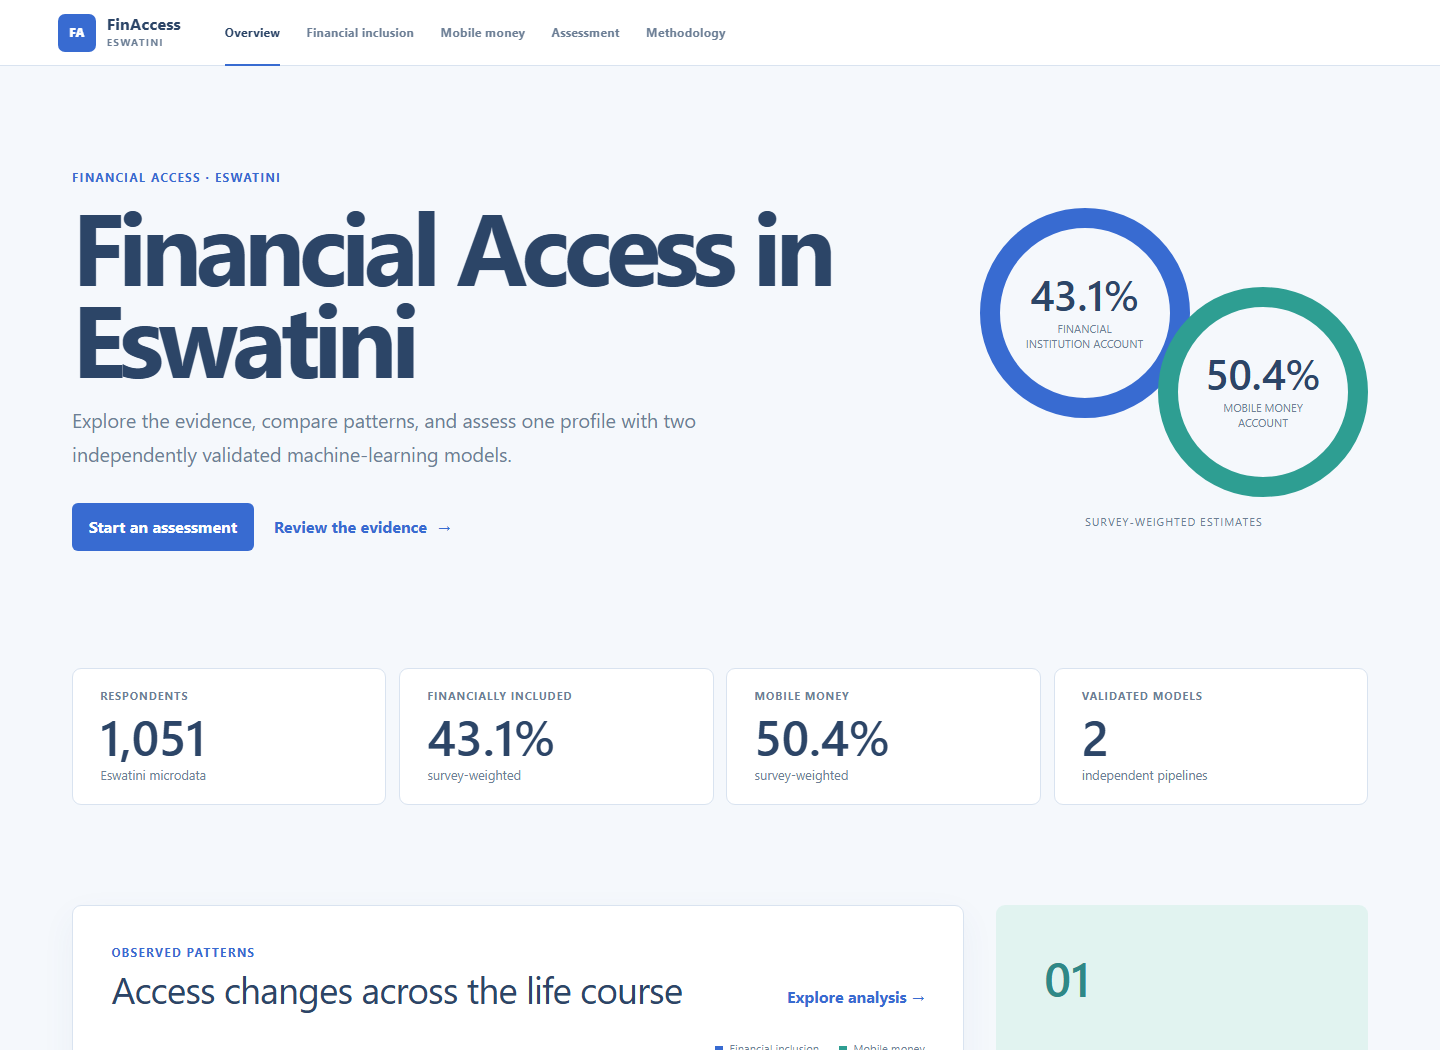

In [3]:
display(Image(filename=str(project_root / 'reports/phase_13/screenshots/01_overview.png')))

## Real two-model assessment response

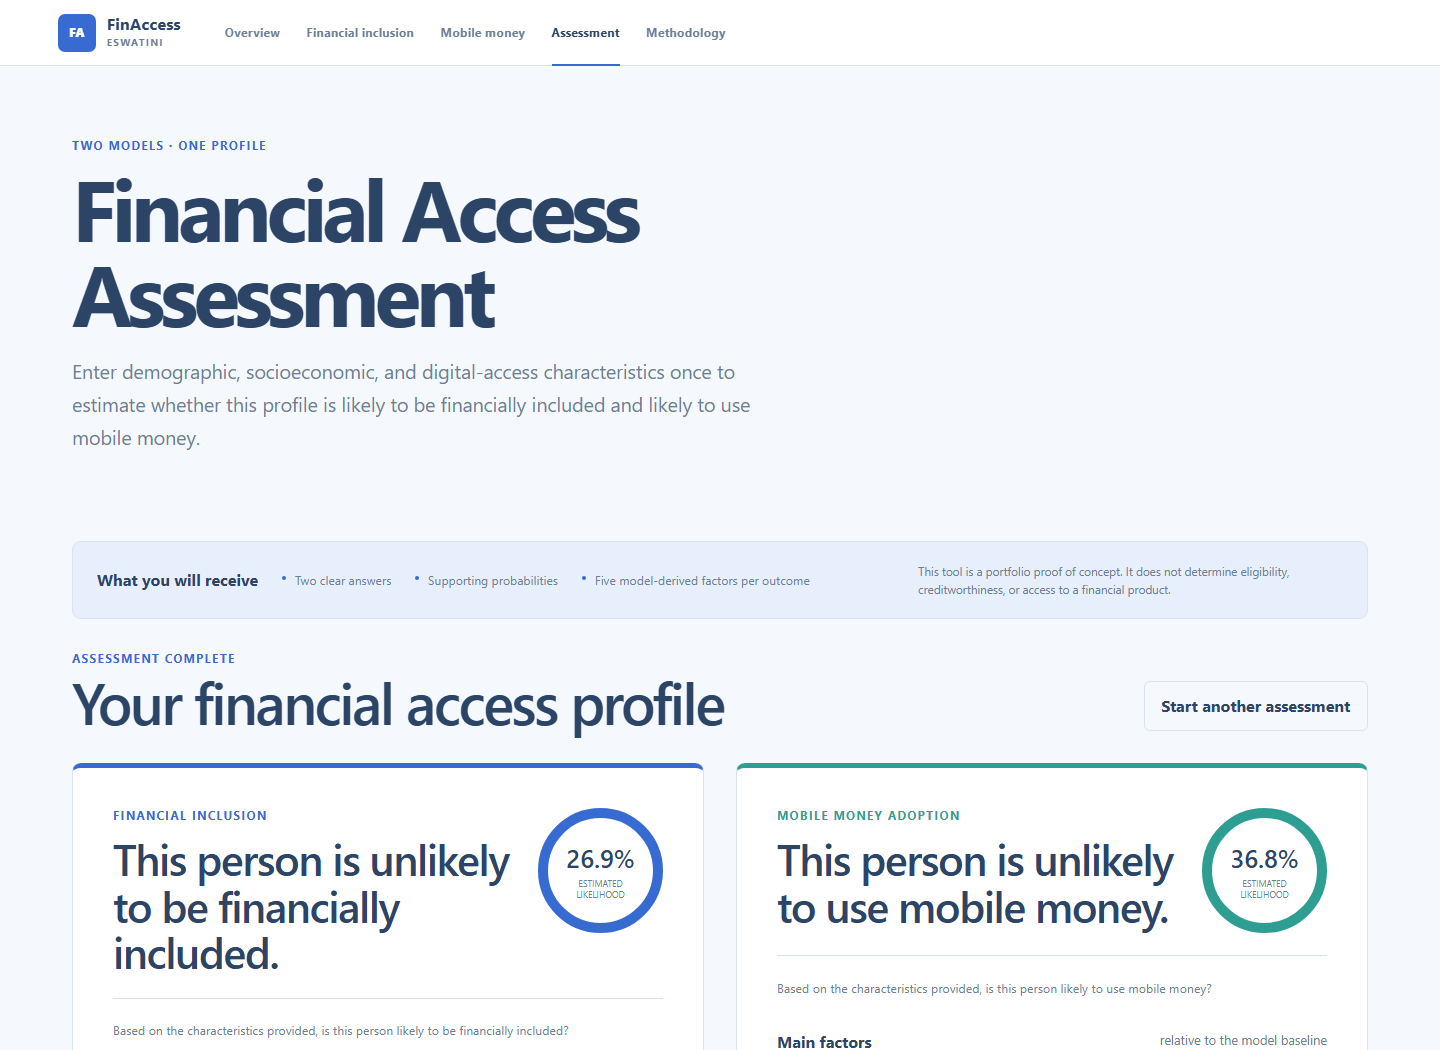

In [4]:
display(Image(filename=str(project_root / 'reports/phase_13/screenshots/03_assessment_results.png')))

## Portfolio evidence

In [5]:
from PIL import Image as PILImage

screenshots = []
for path in sorted((project_root / 'reports/phase_13/screenshots').glob('0[1-4]_*.png')):
    with PILImage.open(path) as image:
        screenshots.append({'Screenshot': path.name, 'Width': image.width, 'Height': image.height, 'Bytes': path.stat().st_size})

notebooks = sorted((project_root / 'notebooks').glob('[01][0-9]_*.ipynb'))
print(f"Completed phase notebooks: {len(notebooks)}")
pd.DataFrame(screenshots)

Completed phase notebooks: 13


,Screenshot,Width,Height,Bytes
0,01_overview.png,1440,1050,105042
1,02_assessment.png,1440,1050,74577
2,03_assessment_results.png,1440,1050,112721
3,04_methodology.png,1440,1050,98003


## Final interpretation boundaries

- The World Bank microdata are observational; associations, predictions, and SHAP contributions do not establish causation.
- The protected holdouts are small and metric uncertainty is material.
- Matching predictor profiles sometimes have conflicting outcomes, limiting deterministic predictability from the available inputs.
- The 0.50 decision thresholds remain provisional.
- Recent digital-behaviour features in Model 2 overlap the outcome observation period and remain a documented conceptual limitation.
- Raw respondent microdata remain local and are excluded from both publishable repositories.
- The public product is a portfolio proof of concept, not a production financial eligibility or decision system.